# A tibble: 2 × 5
  term    `5`  `10`  `15`  `24`
  <chr> <dbl> <dbl> <dbl> <dbl>
1 AGE_c 0.618 0.557 0.605 0.613
2 MALE  0.548 0.539 0.581 0.648
# A tibble: 4 × 3
      t beta0_hat beta0_theory
  <dbl>     <dbl>        <dbl>
1     5      1.92         1.93
2    10      2.77         2.76
3    15      3.26         3.25
4    24      3.68         3.81
# A tibble: 2 × 5
  term  Logistic_Independent Cox_Independent `Logistic_Age-dependent`
  <chr>                <dbl>           <dbl>                    <dbl>
1 AGE_c                0.463           0.33                    -0.025
2 MALE                 0.327           0.261                    0.136
# ℹ 1 more variable: `Cox_Age-dependent` <dbl>


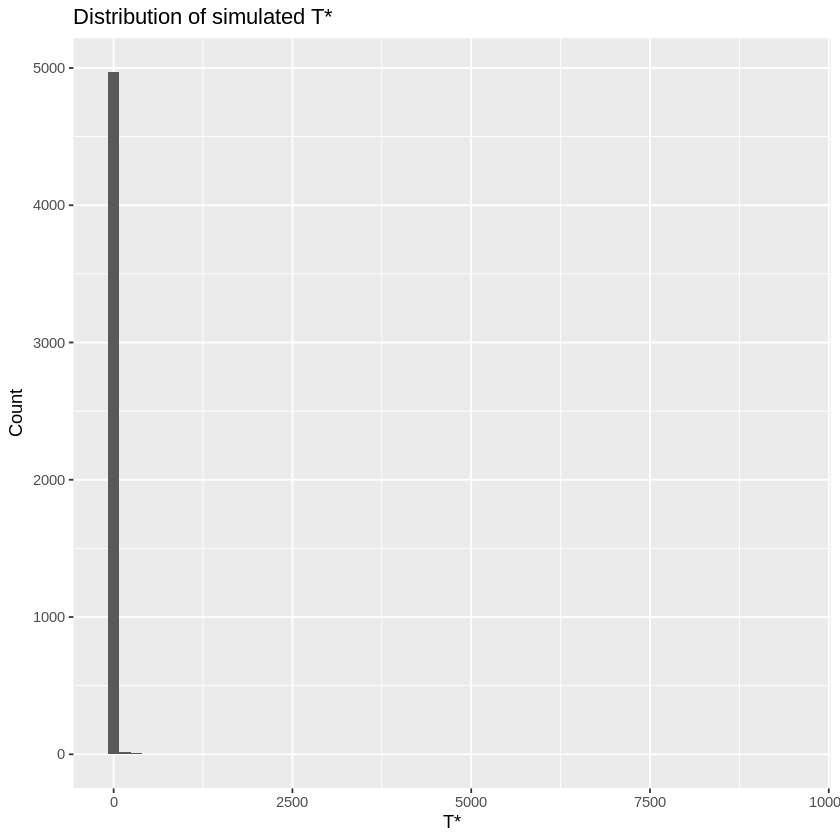

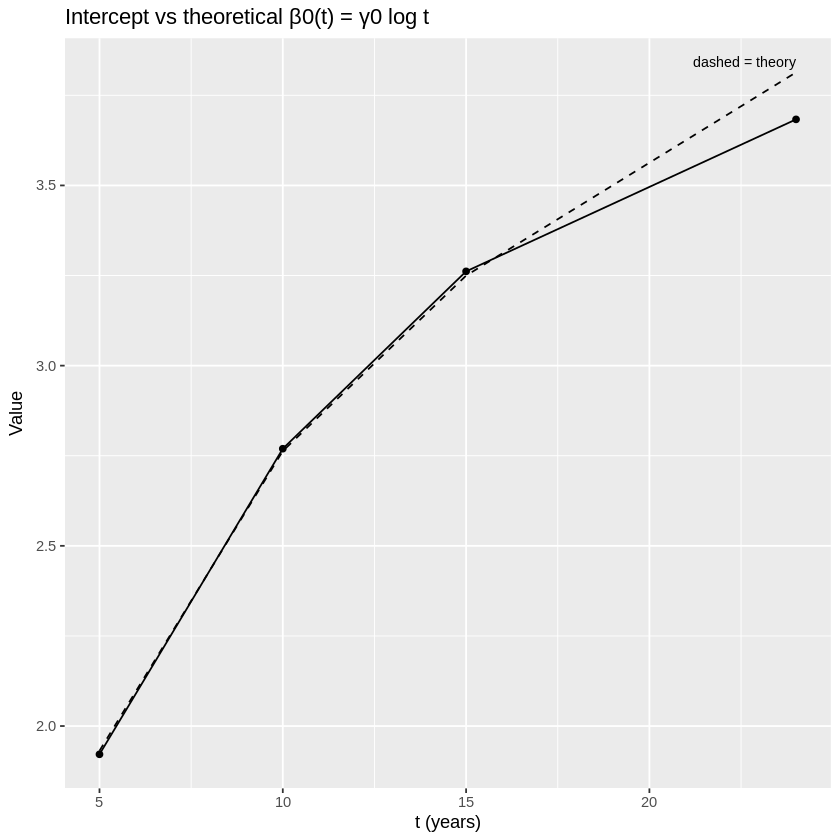

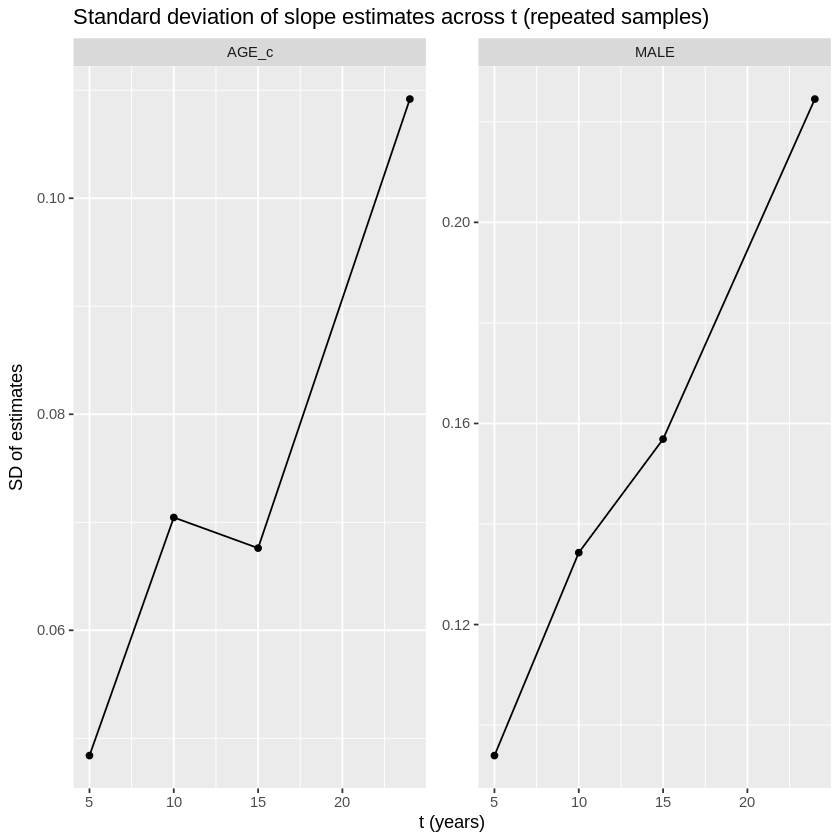

In [ ]:
# Survival theory/sim
# Packages
suppressPackageStartupMessages({
  library(dplyr)
  library(ggplot2)
  library(broom)
  library(purrr)
  library(tidyr)
  library(survival)
})

set.seed(42)

#  Parameters and simulation
n          <- 5000
beta_age   <- 0.6
beta_male  <- 0.5
gamma0     <- 1.2
t_vec      <- c(5, 10, 15, 24)

AGE   <- rnorm(n, mean = 60, sd = 10)
AGE_c <- (AGE - 60) / 10                  # centered by decades
MALE  <- rbinom(n, 1, 0.5)

eta <- beta_age * AGE_c + beta_male * MALE
U   <- runif(n)

#  inverse-transform for S_eta(t) = 1 / (1 + exp(eta) * t^gamma0)
Tstar <- (U / ((1 - U) * exp(eta)))^(1 / gamma0)

df <- tibble(AGE, AGE_c, MALE, eta, U, Tstar)

# Fig 1: Distribution of T*
p1 <- ggplot(df, aes(Tstar)) +
  geom_histogram(bins = 60) +
  labs(title = "Distribution of simulated T*", x = "T*", y = "Count")


# Logistic fits at t = 5,10,15,24 yrs

fit_list <- map(t_vec, function(t) {
  dft <- mutate(df, Yt = as.integer(Tstar <= t))
  glm(Yt ~ AGE_c + MALE, data = dft, family = binomial)
})
names(fit_list) <- as.character(t_vec)

coef_table <- map_dfr(fit_list, ~ tidy(.x), .id = "t")

# Slope tablE
slope_table <- coef_table %>%
  filter(term %in% c("AGE_c", "MALE")) %>%
  select(t, term, estimate) %>%
  mutate(estimate = round(estimate, 3)) %>%
  pivot_wider(names_from = t, values_from = estimate) %>%
  arrange(match(term, c("AGE_c", "MALE")))
print(slope_table)

# Intercept vs theory
intercepts <- map_dfr(t_vec, ~{
  dft  <- mutate(df, Yt = as.integer(Tstar <= .x))
  fit  <- glm(Yt ~ AGE_c + MALE, data = dft, family = binomial)
  tibble(t = .x, beta0_hat = unname(coef(fit)[1]))
}) %>%
  mutate(beta0_theory = gamma0 * log(t))

print(intercepts %>% mutate(across(-t, ~round(.x, 2))))

# Fig 2: Intercept vs theoretical gamma0 * log(t)
p2 <- ggplot(intercepts, aes(x = t)) +
  geom_line(aes(y = beta0_hat)) +
  geom_point(aes(y = beta0_hat)) +
  geom_line(aes(y = beta0_theory), linetype = "dashed") +
  annotate("text", x = max(t_vec), y = max(intercepts$beta0_theory),
           label = "dashed = theory", hjust = 1, vjust = -0.5, size = 3) +
  labs(title = "Intercept vs theoretical β0(t) = γ0 log t",
       x = "t (years)", y = "Value")


# 3) Repeated simulations: SD of slopes vs censoring

n_sim <- 100
get_fit <- function(t){
  AGE  <- rnorm(n, 60, 10); AGE_c <- (AGE - 60)/10
  MALE <- rbinom(n, 1, 0.5)
  eta  <- beta_age * AGE_c + beta_male * MALE
  U    <- runif(n)
  # same  inversion as above
  Tstar <- (U / ((1 - U) * exp(eta)))^(1 / gamma0)
  Yt    <- as.integer(Tstar <= t)
  tidy(glm(Yt ~ AGE_c + MALE, family = binomial))
}

sd_df <- map_dfr(t_vec, function(t){
  ests <- replicate(n_sim, get_fit(t), simplify = FALSE)
  bind_rows(ests) %>%
    filter(term %in% c("AGE_c", "MALE")) %>%
    group_by(term) %>%
    summarise(t = t, sd = sd(estimate), .groups = "drop")
})

p3 <- ggplot(sd_df, aes(x = t, y = sd)) +
  geom_line() + geom_point() +
  facet_wrap(~ term, scales = "free_y") +
  labs(title = "Standard deviation of slope estimates across t (repeated samples)",
       x = "t (years)", y = "SD of estimates")

# 4) Death censoring: independent vs age-dependent censoring

# Independent censoring on [0,24]
C_indep <- runif(n, 0, 24)
Y_indep <- as.integer(Tstar <= C_indep)
logit_indep <- glm(Y_indep ~ AGE_c + MALE, family = binomial)
cox_indep   <- coxph(Surv(pmin(Tstar, C_indep), Y_indep) ~ AGE_c + MALE)

#  age-dependent) censoring
lambda <- 0.08 * exp(0.5 * AGE_c + 0.2 * MALE)
C_age  <- rexp(n, rate = lambda)
Y_age  <- as.integer(Tstar <= C_age)
logit_age <- glm(Y_age ~ AGE_c + MALE, family = binomial)
cox_age   <- coxph(Surv(pmin(Tstar, C_age), Y_age) ~ AGE_c + MALE)

#  comparison table (coefficients only)
grab_coefs <- function(fit) {
  broom::tidy(fit) %>% filter(term %in% c("AGE_c", "MALE")) %>%
    select(term, estimate)
}
tab_compare <- bind_rows(
  grab_coefs(logit_indep) %>% mutate(model = "Logistic", censor = "Independent"),
  grab_coefs(cox_indep)   %>% mutate(model = "Cox",     censor = "Independent"),
  grab_coefs(logit_age)   %>% mutate(model = "Logistic", censor = "Age-dependent"),
  grab_coefs(cox_age)     %>% mutate(model = "Cox",      censor = "Age-dependent")
) %>%
  mutate(estimate = round(estimate, 3)) %>%
  pivot_wider(names_from = c(model, censor), values_from = estimate) %>%
  arrange(match(term, c("AGE_c", "MALE")))
print(tab_compare)

p1
p2
p3

In [ ]:
install.packages("riskCommunicator")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘rbibutils’, ‘Deriv’, ‘microbenchmark’, ‘Rdpack’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘corrplot’, ‘car’, ‘ggrepel’, ‘ggsci’, ‘cowplot’, ‘ggsignif’, ‘gridExtra’, ‘polynom’, ‘rstatix’, ‘ggpubr’




In [ ]:
# EDA Continued
library(riskCommunicator)
data(framingham, package = "riskCommunicator")
df <- framingham

## Dimensions, individuals, periods
cat("Rows:", nrow(df), " | Cols:", ncol(df), "\n")
cat("Unique participants (RANDID):", length(unique(df$RANDID)), "\n")
cat("Rows per PERIOD:\n"); print(table(df$PERIOD, useNA = "ifany"))
cat("\nRows per participant (summary):\n"); print(summary(table(df$RANDID)))

##  Variable types, uniques, missingness
var_summary <- data.frame(
  variable = names(df),
  class    = sapply(df, function(x) paste(class(x), collapse = "/")),
  n_unique = sapply(df, function(x) length(unique(x))),
  n_miss   = sapply(df, function(x) sum(is.na(x))),
  pct_miss = round(sapply(df, function(x) mean(is.na(x))*100), 2),
  stringsAsFactors = FALSE
)
# Heuristic binary check (0/1 only after removing NAs)
is_binary <- sapply(df, function(x) {
  v <- unique(na.omit(x))
  is.numeric(x) && length(v) <= 2 && all(v %in% c(0,1))
})
var_summary$is_binary <- is_binary
print(var_summary[order(-var_summary$pct_miss, var_summary$variable), ], row.names = FALSE)

##  Lipids availability by PERIOD
cat("\nHDLC non-missing by PERIOD:\n"); print(table(df$PERIOD[!is.na(df$HDLC)], useNA="ifany"))
cat("\nLDLC non-missing by PERIOD:\n"); print(table(df$PERIOD[!is.na(df$LDLC)], useNA="ifany"))

## Outcomes: prevalence (mean of 1s)
outcomes <- c("CVD","ANYCHD","MI_FCHD","STROKE","ANGINA","HOSPMI","DEATH","HYPERTEN")
out_prev <- sapply(outcomes, function(v) mean(df[[v]] == 1, na.rm = TRUE))
out_prev <- sort(out_prev, decreasing = TRUE)
cat("\nOutcome prevalences (proportion of 1s):\n"); print(round(out_prev, 3))

##  Time variables: ranges/summaries
time_vars <- c("TIME","TIMECVD","TIMEAP","TIMEMI","TIMEMIFC","TIMECHD","TIMESTRK","TIMEDTH","TIMEHYP")
cat("\nTime variable summaries (in days):\n")
print(sapply(df[time_vars], function(x) summary(x)), max = 1000)

##  Basic consistency checks
# Are binary variables truly 0/1?
bin_check <- names(df)[is_binary]
bin_ok <- sapply(df[bin_check], function(x) all(na.omit(x) %in% c(0,1)))
cat("\nBinary 0/1 check (all TRUE expected):\n"); print(bin_ok)

# Are any times negative?
neg_time_counts <- sapply(df[time_vars], function(x) sum(!is.na(x) & x < 0))
cat("\nNegative values in time variables (all zeros expected):\n"); print(neg_time_counts)

## quick numeric correlation snapshot
risk_vars <- intersect(c("AGE","SYSBP","DIABP","TOTCHOL","BMI","GLUCOSE","HEARTRTE"), names(df))
if (length(risk_vars) > 1) {
  cat("\nCorrelation matrix among key continuous risk factors:\n")
  print(round(cor(df[risk_vars], use = "pairwise.complete.obs"), 3))
}

##  Missingness by PERIOD (optional stratified view)
miss_by_period <- do.call(rbind, lapply(split(df, df$PERIOD), function(d) {
  data.frame(
    PERIOD   = unique(d$PERIOD),
    variable = names(d),
    pct_miss = round(sapply(d, function(x) mean(is.na(x))*100), 2)
  )
}))
cat("\nMissingness % by PERIOD (head):\n"); print(head(miss_by_period[order(-miss_by_period$pct_miss), ], 20), row.names = FALSE)


Rows: 11627  | Cols: 39 
Unique participants (RANDID): 4434 
Rows per PERIOD:

   1    2    3 
4434 3930 3263 

Rows per participant (summary):
Number of cases in table: 11627 
Number of factors: 1 
 variable   class n_unique n_miss pct_miss is_binary
     HDLC numeric      106   8600    73.97     FALSE
     LDLC numeric      263   8601    73.97     FALSE
  GLUCOSE numeric      212   1440    12.38     FALSE
   BPMEDS numeric        3    593     5.10      TRUE
  TOTCHOL numeric      300    409     3.52     FALSE
     educ numeric        5    295     2.54     FALSE
  CIGPDAY numeric       46     79     0.68     FALSE
      BMI numeric     1819     52     0.45     FALSE
 HEARTRTE numeric       84      6     0.05     FALSE
      AGE numeric       50      0     0.00     FALSE
   ANGINA numeric        2      0     0.00      TRUE
   ANYCHD numeric        2      0     0.00      TRUE
 CURSMOKE numeric        2      0     0.00      TRUE
      CVD numeric        2      0     0.00      TRUE
    DE

Warning message:
“Removed 52 rows containing non-finite outside the scale range
(`stat_density()`).”
Warning message:
“Removed 19 rows containing non-finite outside the scale range
(`stat_density()`).”
Warning message:
“Removed 397 rows containing non-finite outside the scale range
(`stat_density()`).”
Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_density()`).”


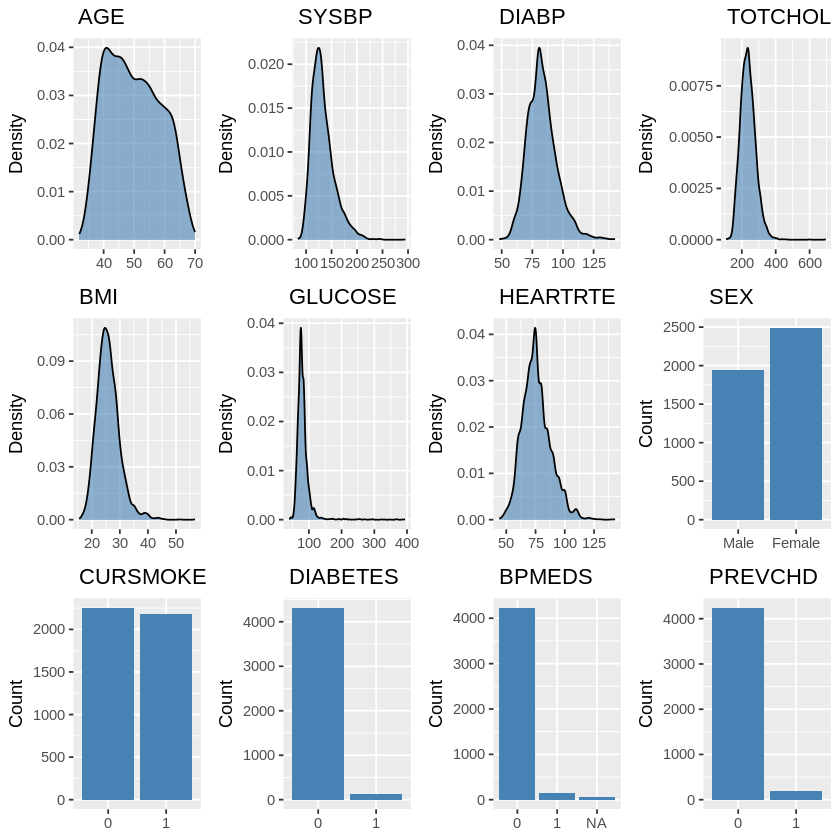

In [ ]:
library(dplyr)

# columns expected to be binary 0/1
bin_vars <- c("CURSMOKE","DIABETES","BPMEDS","PREVCHD","PREVAP",
              "PREVSTRK","PREVHYP","CVD","HYPERTEN")

# make clean factors
df <- df %>%
  mutate(
    across(all_of(bin_vars),
           ~ factor(., levels = c(0,1), labels = c("0","1"))),
    SEX    = factor(SEX, levels = c(1,2), labels = c("Male","Female")),
    PERIOD = factor(PERIOD, levels = c(1,2,3), labels = c("1","2","3"))
  )



p1 <- subset ( df , PERIOD == 1)
continuous <- c ( " AGE " ," SYSBP " ," DIABP " ," TOTCHOL " ," BMI " ," GLUCOSE " ," HEARTRTE " )
categorical <- c ( " SEX " ," CURSMOKE " ," DIABETES " ," BPMEDS " ," PREVCHD " )
plots_cont <- lapply ( continuous , function ( v ) {
ggplot ( p1 , aes_string ( x = v ) ) +
geom_density ( fill = " steelblue " , alpha = 0.6) +
labs ( title = v , x = NULL , y = " Density " )
})
plots_cat <- lapply ( categorical , function ( v ) {
ggplot ( p1 , aes_string ( x = v ) ) +
geom_bar ( fill = " steelblue " ) +
labs ( title = v , x = NULL , y = " Count " )
})
gridExtra :: grid.arrange ( grobs = c ( plots_cont , plots_cat ) , nrow = 3 , ncol = 4)